In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import pandas as pd
import xarray as xr

# Single exposure array with time axis
exposure = xr.concat(
    [
        xr.open_dataarray(
            "data/exposure/deu_ppp_2000_UNadj.tif",
            chunks="auto",
            decode_coords="all",
            engine="rasterio",
        ),
        xr.open_dataarray(
            "data/exposure/deu_ppp_2001_UNadj.tif",
            chunks="auto",
            decode_coords="all",
            engine="rasterio",
        ),
    ],
    dim=pd.DatetimeIndex(["2021-06-12", "2021-06-15"], name="time"),
)
exposure = exposure.squeeze()  # band

# exposure = xr.open_dataarray(
#     "data/exposure/deu_ppp_2000_UNadj.tif",
#     chunks="auto",
#     decode_coords="all",
#     engine="rasterio",
# ).squeeze()
# exposure = (
#     exposure.sel(x=slice(5.88, 5.89), y=slice(55, 54.99)).chunk("auto")
# )
# exposure = exposure.rename({"x": "longitude", "y": "latitude"})
exposure

<xarray.DataArray 'band_data' (time: 2, y: 9345, x: 10999)> Size: 822MB
dask.array<getitem, shape=(2, 9345, 10999), dtype=float32, chunksize=(1, 2560, 10999), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y            (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 16B 2021-06-12 2021-06-15
Attributes:
    AREA_OR_POINT:  Area

In [4]:
# exposure = xr.Dataset(
#     {
#         "exp1": xr.open_dataarray(
#             "data/exposure/deu_ppp_2000_UNadj.tif",
#             chunks="auto",
#             decode_coords="all",
#             engine="rasterio",
#         ),
#         "exp2": xr.open_dataarray(
#             "data/exposure/deu_ppp_2001_UNadj.tif",
#             chunks="auto",
#             decode_coords="all",
#             engine="rasterio",
#         ),
#     }
# )
# exposure = exposure.squeeze()  # band
# exposure

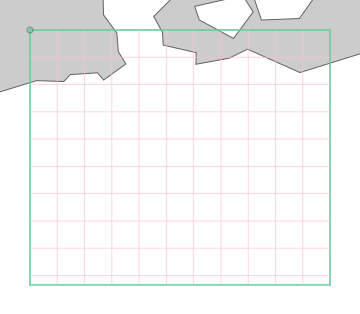

In [2]:
import odc.geo.xr  # noqa: F401

exposure.odc.geobox

In [3]:
from functools import partial
import numpy as np


def impact_func(intensity, threshold, half_point, exponent, scale):
    luk = (intensity - threshold) / (half_point - threshold)
    # luk = np.where(luk < 0, 0, luk)
    return np.maximum(scale * luk**exponent / (1 + luk**exponent), 0.0)


# impf = partial(impact_func, threshold=0.1, half_point=1.0, scale=1.0, exponent=3)
impf = lambda intensity: impact_func(
    intensity, threshold=0.1, half_point=1.0, scale=1.0, exponent=3
)

In [4]:
import odc.geo.xr  # noqa: F401

hazard = xr.open_dataset(
    "data/hazard/flood-2021-06-fine.nc", chunks="auto", decode_coords="all"
)["flood_depth"]
hazard = hazard.odc.assign_crs("EPSG:4326")
hazard = hazard.isel(time=0, drop=True)
# hazard = hazard.sel(time=exposure["time"])
# hazard = hazard.sel(longitude=slice(5.88, 5.89), latitude=slice(55, 54.99)).isel(number=0, time=0, step=0).chunk("auto")

# To dataset
hazard

# hazard = xr.DataArray(
#     data=hazard.data.map_blocks(lambda x: sparse.COO(x, fill_value=np.nan)),
#     coords=hazard.coords,
#     attrs=hazard.attrs,
# )
# hazard.data.dtype

/var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/ipykernel_95107/3687274010.py:3: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  hazard = xr.open_dataset(


<xarray.DataArray 'flood_depth' (latitude: 1859, longitude: 2183, number: 10,
                                 step: 5)> Size: 812MB
dask.array<getitem, shape=(1859, 2183, 10, 5), dtype=float32, chunksize=(620, 728, 4, 1), chunktype=numpy.ndarray>
Coordinates:
  * number       (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * step         (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
    surface      float64 8B ...
    valid_time   (step) datetime64[ns] 40B dask.array<chunksize=(5,), meta=np.ndarray>
  * longitude    (longitude) float64 17kB 5.878 5.883 5.887 ... 14.97 14.97
  * latitude     (latitude) float64 15kB 55.02 55.02 55.01 ... 47.29 47.28 47.28
    spatial_ref  int32 4B 4326

In [5]:
import climadace

hazard = climadace.reproject_hazard(
    hazard,
    exposure,
    resampling="nearest",
    cache_result=False,
    align_chunks=True,
    force_reproject=False,
)

reindex


/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(


Frozen({'y': (2560, 2560, 2560, 1665), 'x': (10999,), 'number': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'step': (1, 1, 1, 1, 1)})


In [6]:
from dask.base import visualize
from dask.distributed import Client
import xarray as xr

import climadace

# hazard = xr.open_dataset(
#     "data/hazard/flood-2021-06-fine.nc", chunks="auto", decode_coords="all"
# )["flood_depth"]
# hazard = hazard.odc.assign_crs("EPSG:4326")
# hazard = hazard.sel(time=exposure["time"])
# hazard = xr.DataArray(
#     data=hazard.data.map_blocks(lambda x: sparse.COO(x, fill_value=np.nan)),
#     coords=hazard.coords,
#     attrs=hazard.attrs,
# )
# name = hazard.name

# with Client(n_workers=1, threads_per_worker=4, memory_limit="4GB"):

impact = impf(hazard) * exposure
    # impact = hazard
impact = climadace.norm_chunks(impact)
    # impact = xr.apply_ufunc(
    #     lambda x: x.todense(),
    #     impact,
    #     dask="parallelized",
    #     output_dtypes=["float"],
    # )
    # impact = xr.map_blocks(
    #     lambda x: xr.Dataset(
    #         {name: x[name].data.todense()}, coords=impact.coords, attrs=impact.attrs
    #     ),
    #     impact,
    #     template=impact,
    # )
    # delayed = impact.to_zarr("data/output/flood.zarr", mode="w", compute=False)
    # visualize(delayed, filename="impact", format="pdf", optimize_graph=True)

impact

# delayed.dask

<xarray.DataArray (y: 9345, x: 10999, number: 10, step: 5, time: 2)> Size: 41GB
dask.array<mul, shape=(9345, 10999, 10, 5, 2), dtype=float32, chunksize=(2560, 10999, 1, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
  * x           (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y           (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 40B dask.array<chunksize=(1,), meta=np.ndarray>
    band        int64 8B 1
  * time        (time) datetime64[ns] 16B 2021-06-12 2021-06-15

In [10]:
with Client(n_workers=1, threads_per_worker=2, memory_limit="4GB"):
    impact.to_zarr("data/output/flood.zarr", mode="w")

/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/zarr/api/asynchronous.py:213: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Task exception was never retrieved
future: <Task finished name='Task-225' coro=<Client._gather.<locals>.wait() done, defined at /Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/distributed/client.py:2377> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/distributed/client.py", line 2386, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-226' coro=<Client._gather.<locals>.wait() done, defined at /Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/distributed/client

KeyboardInterrupt: 

## Try sampling

In [7]:
import itertools
samples = list(itertools.product(exposure["time"], hazard["number"], hazard["step"]))


In [8]:
hazard.sel(number=samples[0][1], step=samples[0][2]) * exposure.sel(time=samples[0][0])

<xarray.DataArray (y: 9345, x: 10999)> Size: 411MB
dask.array<mul, shape=(9345, 10999), dtype=float32, chunksize=(2560, 10999), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 1
    step        timedelta64[ns] 8B 1 days
  * x           (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y           (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    band        int64 8B 1
    time        datetime64[ns] 8B 2021-06-12

In [11]:
import itertools
import pandas as pd
import numpy as np

impact = []
samples = list(itertools.product(exposure["time"], hazard["number"], hazard["step"]))

print(len(samples))
for time, number, step in samples:
    impact.append(impf(hazard.sel(number=number, step=step)) * exposure.sel(time=time))

impact = xr.concat(impact, dim=pd.Index(list(range(len(impact))), name="sample"))
impact

100


<xarray.DataArray (sample: 100, y: 9345, x: 10999)> Size: 41GB
dask.array<concatenate, shape=(100, 9345, 10999), dtype=float32, chunksize=(1, 2560, 10999), chunktype=numpy.ndarray>
Coordinates:
    number      (sample) int64 800B 1 1 1 1 1 2 2 2 2 ... 9 9 9 9 10 10 10 10 10
    step        (sample) timedelta64[ns] 800B 1 days 2 days ... 4 days 5 days
  * x           (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y           (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    surface     float64 8B 0.0
    valid_time  (sample) datetime64[ns] 800B dask.array<chunksize=(1,), meta=np.ndarray>
    band        int64 8B 1
    time        (sample) datetime64[ns] 800B 2021-06-12 ... 2021-06-15
  * sample      (sample) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99

In [12]:
with Client(n_workers=1, threads_per_worker=2, memory_limit="4GB"):
    impact.to_zarr("data/output/flood.zarr", mode="w")

/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/zarr/api/asynchronous.py:213: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [17]:
samples = pd.DataFrame.from_records(
    itertools.product(
        exposure["time"].to_numpy(),
        hazard["number"].to_numpy(),
        hazard["step"].to_numpy(),
    ),
    columns=["time", "number", "step"],
)
samples

,time,number,step
0,2021-06-12,1,1 days
1,2021-06-12,1,2 days
2,2021-06-12,1,3 days
3,2021-06-12,1,4 days
4,2021-06-12,1,5 days
...,...,...,...
95,2021-06-15,10,1 days
96,2021-06-15,10,2 days
97,2021-06-15,10,3 days
98,2021-06-15,10,4 days


WARNING! This is much less efficient, because much more data is loaded at once!

In [18]:
number = xr.DataArray(samples["number"], dims="sample")
time = xr.DataArray(samples["time"], dims="sample")
step = xr.DataArray(samples["step"], dims="sample")
impact = impf(hazard.sel(number=number, step=step)) * exposure.sel(time=time)
impact

<xarray.DataArray (y: 9345, x: 10999, sample: 100)> Size: 41GB
dask.array<mul, shape=(9345, 10999, 100), dtype=float32, chunksize=(2560, 10999, 1), chunktype=numpy.ndarray>
Coordinates:
    number      (sample) int64 800B 1 1 1 1 1 2 2 2 2 ... 9 9 9 9 10 10 10 10 10
    step        (sample) timedelta64[ns] 800B 1 days 2 days ... 4 days 5 days
  * x           (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y           (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    surface     float64 8B 0.0
    valid_time  (sample) datetime64[ns] 800B dask.array<chunksize=(1,), meta=np.ndarray>
  * sample      (sample) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
    band        int64 8B 1
    time        (sample) datetime64[ns] 800B 2021-06-12 ... 2021-06-15

In [19]:
with Client(n_workers=1, threads_per_worker=2, memory_limit="4GB"):
    impact.transpose("sample", "x", "y").to_zarr("data/output/flood.zarr", mode="w")

/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/zarr/api/asynchronous.py:213: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Task exception was never retrieved
future: <Task finished name='Task-331748' coro=<Client._gather.<locals>.wait() done, defined at /Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/distributed/client.py:2377> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/distributed/client.py", line 2386, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-331749' coro=<Client._gather.<locals>.wait() done, defined at /Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/distributed/

KeyboardInterrupt: 